In [1]:
import scimap as sm
import numpy as np
import matplotlib.pyplot as plt
import anndata as ad
import pandas as pd
import scanpy as sc
import scipy as sp
import os
import yaml
from pathlib import Path
from matplotlib import colormaps
import seaborn as sns

Running SCIMAP  2.2.9


/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



In [2]:
preprocessed_dir = Path("/Users/jawadalaaedeen/Desktop/PhD/NMC/preprocessed")
roi_list = [roi for roi in preprocessed_dir.iterdir() if roi.is_dir() and roi.name != '.DS_Store']

In [31]:
#conctenate all the adata files
adata_list = []
for roi in roi_list:
    adata = ad.read_h5ad(roi / "adata.h5ad")
    adata_list.append(adata)
adata = ad.concat(adata_list)
#make obs names unique
adata.obs_names_make_unique()
adata.obs.run = adata.obs.run.astype("category")
adata.obs.patient_ID = adata.obs.patient_ID.astype("category")
#normalize adata.X by dividing the values of each row by the row's Cell 3D volume from obs
adata.raw = adata.copy()
adata.X = adata.X / adata.obs["Cell 3D Volume"].values[:, None]
#do variance stabilizing transformation via square root
adata.X = np.sqrt(adata.X)

/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.10/site-packages/anndata/_core/merge.py:1280: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning:

Observation names are not unique. To make them unique, call `.obs_names_make_unique`.



In [ ]:
sc.

In [29]:
sc.pp.scale(adata)
sc.pp.combat(adata, key="patient_ID")

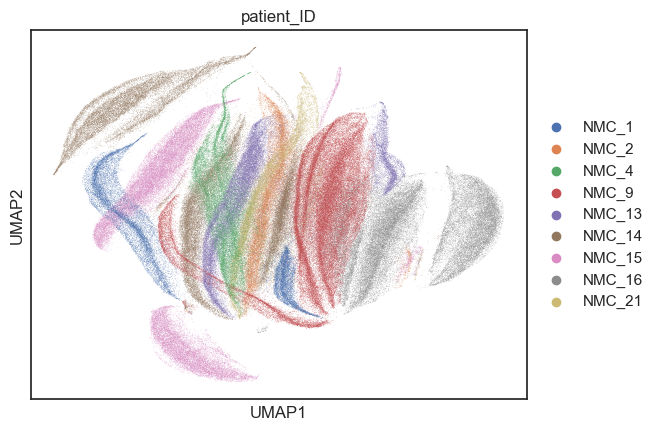

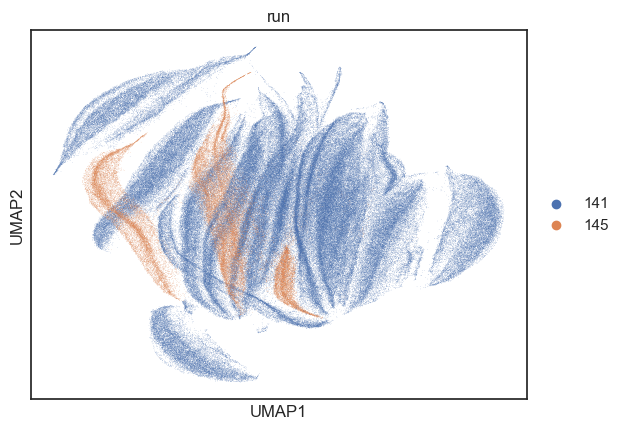

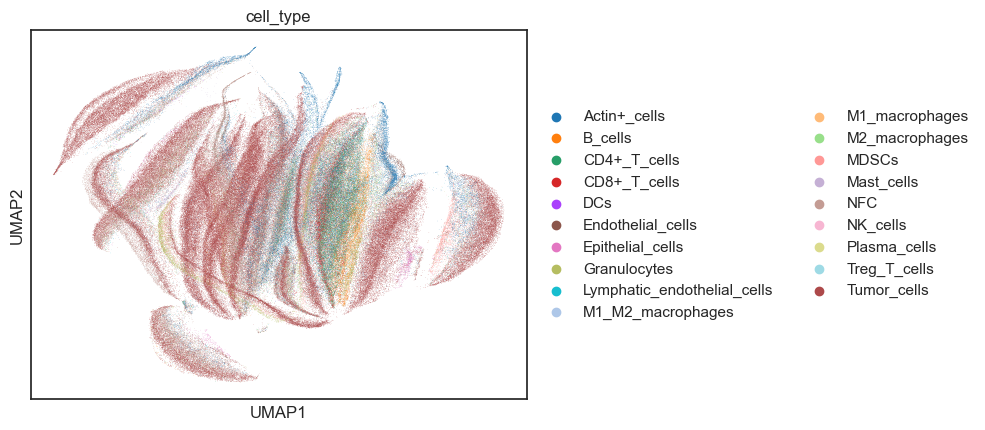

In [30]:
sc.pp.neighbors(adata, use_rep="X")
sc.tl.umap(adata)
sc.pl.umap(adata, color="patient_ID")
sc.pl.umap(adata, color="run")
sc.pl.umap(adata, color="cell_type")

In [17]:
#conctenate all the adata files
adata_list = []
for roi in roi_list:
    adata = ad.read_h5ad(roi / "adata.h5ad")
    adata_list.append(adata)
adata = ad.concat(adata_list)

#make obs names unique
adata.obs_names_make_unique()
adata.obs.run = adata.obs.run.astype("category")
adata.obs.patient_ID = adata.obs.patient_ID.astype("category")
#normalize adata.X by dividing the values of each row by the row's Cell 3D volume from obs
adata.raw = adata.copy()
adata.X = adata.X / adata.obs["Cell 3D Volume"].values[:, None]
#do variance stabilizing transformation via square root
adata.X = np.sqrt(adata.X)

/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.10/site-packages/anndata/_core/merge.py:1280: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning:

Observation names are not unique. To make them unique, call `.obs_names_make_unique`.



In [18]:
sc.pp.scale(adata)
sc.pp.pca(adata)
sc.external.pp.harmony_integrate(adata, key="run")
adata.obsm["X_pca"] = adata.obsm["X_pca_harmony"]

2025-03-07 13:21:59,140 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-03-07 13:22:14,603 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-03-07 13:22:15,291 - harmonypy - INFO - Iteration 1 of 10
2025-03-07 13:23:19,540 - harmonypy - INFO - Iteration 2 of 10
2025-03-07 13:24:28,100 - harmonypy - INFO - Iteration 3 of 10
2025-03-07 13:25:31,304 - harmonypy - INFO - Converged after 3 iterations


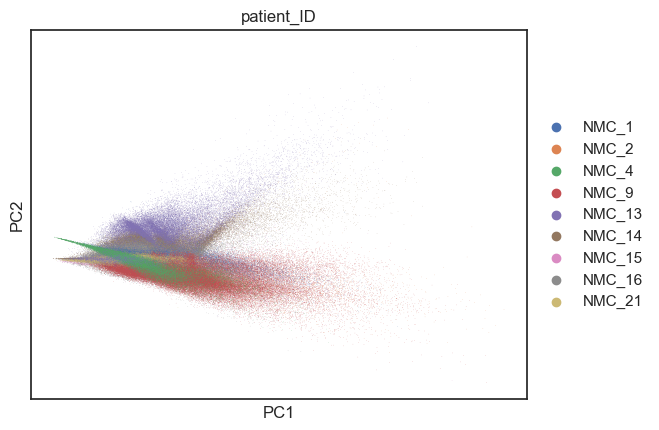

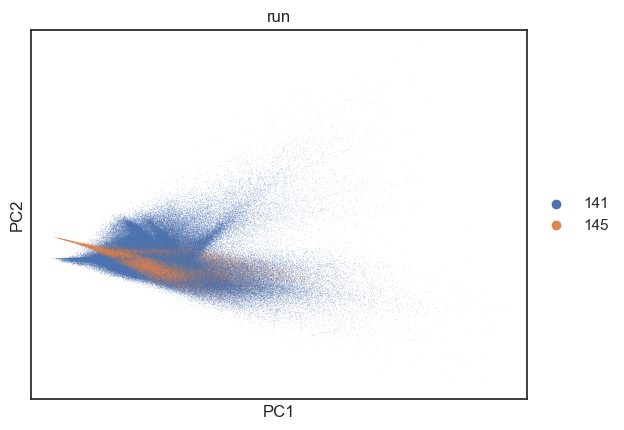

In [8]:
sc.pl.pca_scatter(adata, color="patient_ID")
sc.pl.pca_scatter(adata, color = "run")

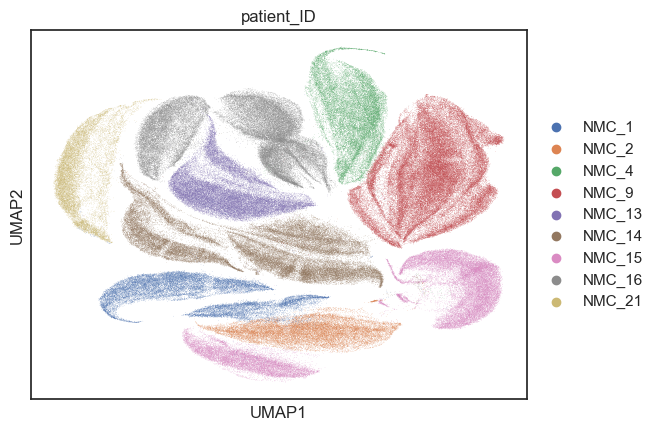

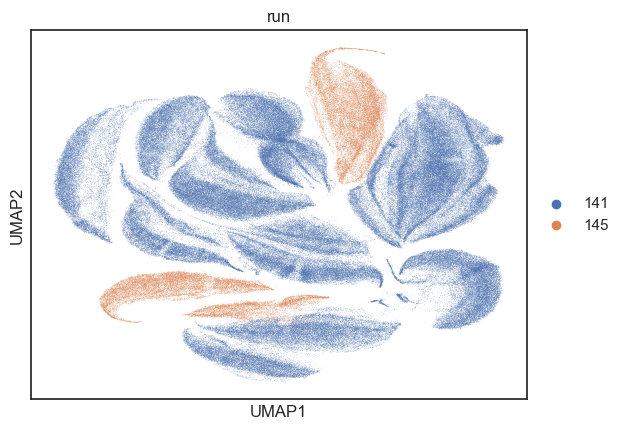

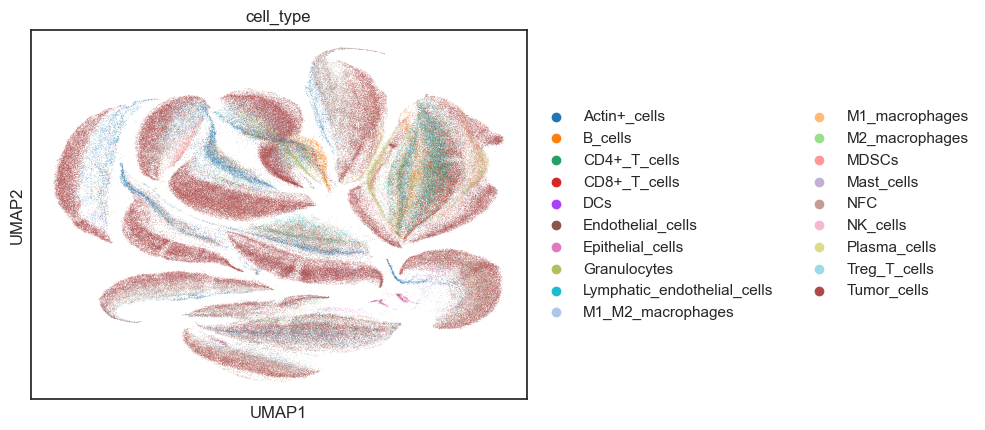

In [9]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color="patient_ID")
sc.pl.umap(adata, color="run")
sc.pl.umap(adata, color="cell_type")

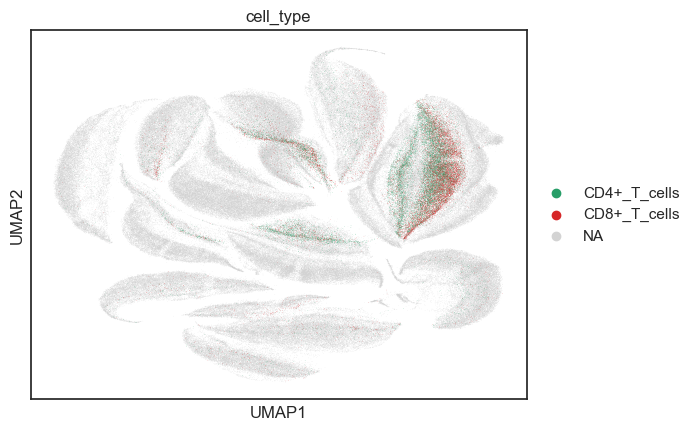

In [10]:
sc.pl.umap(adata, color="cell_type", groups=["CD4+_T_cells", "CD8+_T_cells"])

In [11]:
#conctenate all the adata files
adata_list = []
for roi in roi_list:
    adata = ad.read_h5ad(roi / "adata.h5ad")
    adata_list.append(adata)
adata = ad.concat(adata_list)

#make obs names unique
adata.obs_names_make_unique()
adata.obs.run = adata.obs.run.astype("category")
adata.obs.patient_ID = adata.obs.patient_ID.astype("category")
#normalize adata.X by dividing the values of each row by the row's Cell 3D volume from obs
adata.raw = adata.copy()
adata.X = adata.X / adata.obs["Cell 3D Volume"].values[:, None]
#do variance stabilizing transformation via square root
adata.X = np.sqrt(adata.X)

/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.10/site-packages/anndata/_core/merge.py:1280: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning:

Observation names are not unique. To make them unique, call `.obs_names_make_unique`.



In [12]:
sc.pp.scale(adata)
sc.pp.pca(adata)
sc.external.pp.harmony_integrate(adata, key="patient_ID")
adata.obsm["X_pca"] = adata.obsm["X_pca_harmony"]

2025-03-07 13:09:16,664 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-03-07 13:09:31,146 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-03-07 13:09:31,802 - harmonypy - INFO - Iteration 1 of 10
2025-03-07 13:10:35,589 - harmonypy - INFO - Iteration 2 of 10
2025-03-07 13:11:48,882 - harmonypy - INFO - Iteration 3 of 10
2025-03-07 13:13:06,851 - harmonypy - INFO - Converged after 3 iterations


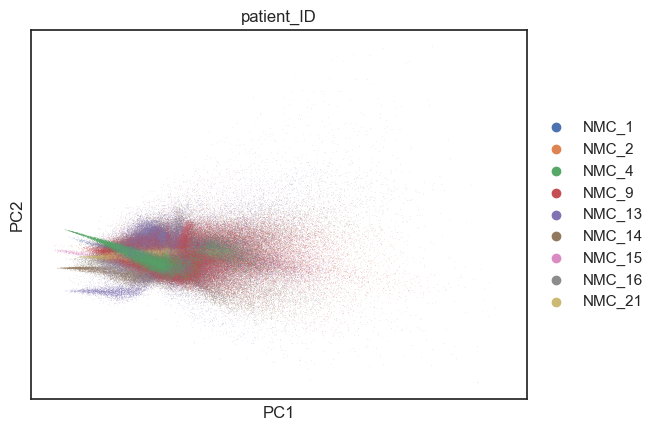

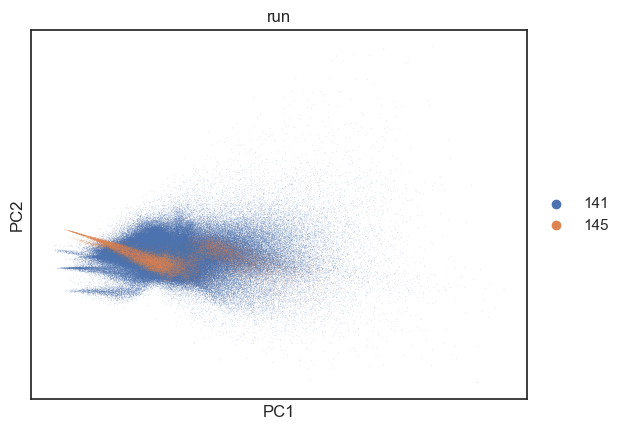

In [13]:
sc.pl.pca_scatter(adata, color="patient_ID")
sc.pl.pca_scatter(adata, color = "run")

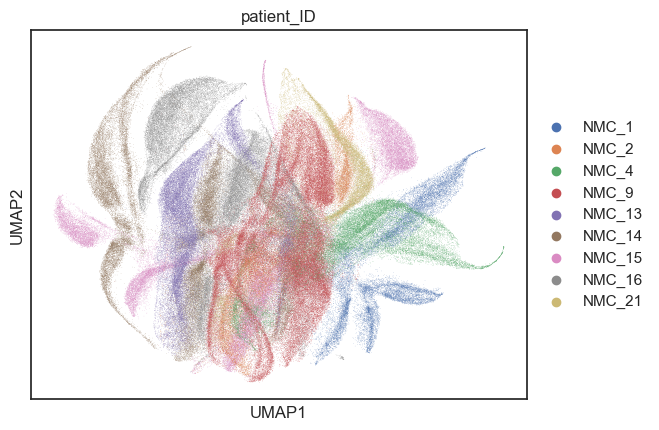

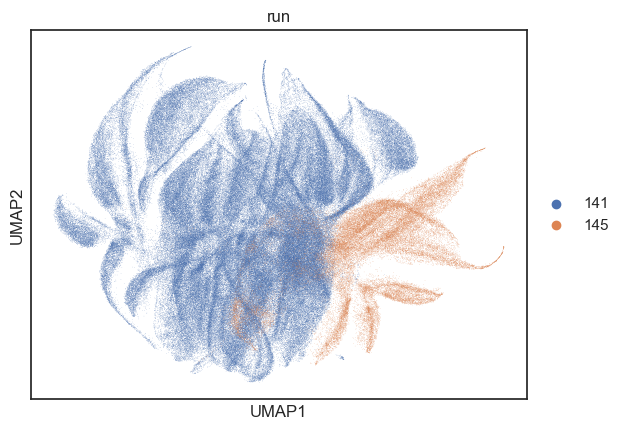

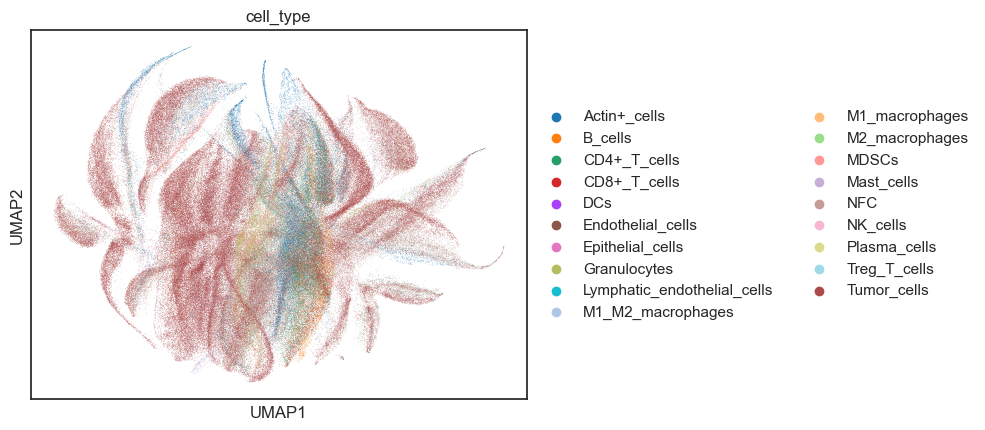

In [14]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color="patient_ID")
sc.pl.umap(adata, color="run")
sc.pl.umap(adata, color="cell_type")

In [ ]:
#conctenate all the adata files
adata_list = []
for roi in roi_list:
    adata = ad.read_h5ad(roi / "adata.h5ad")
    adata_list.append(adata)
adata = ad.concat(adata_list)

#make obs names unique
adata.obs_names_make_unique()
adata.obs.run = adata.obs.run.astype("category")
adata.obs.patient_ID = adata.obs.patient_ID.astype("category")
#normalize adata.X by dividing the values of each row by the row's Cell 3D volume from obs
adata.raw = adata.copy()
adata.X = adata.X / adata.obs["Cell 3D Volume"].values[:, None]
#do variance stabilizing transformation via square root
adata.X = np.sqrt(adata.X)

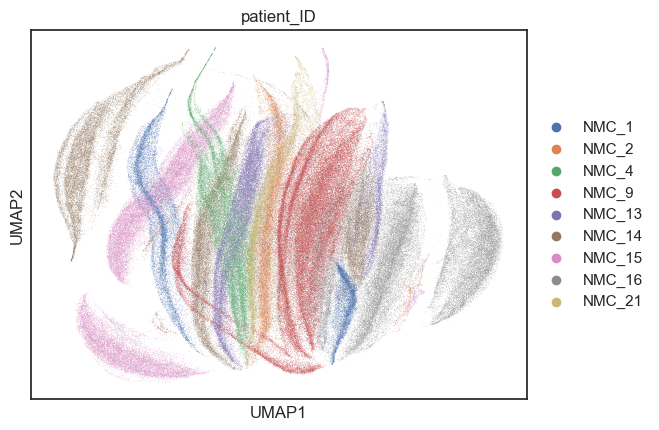

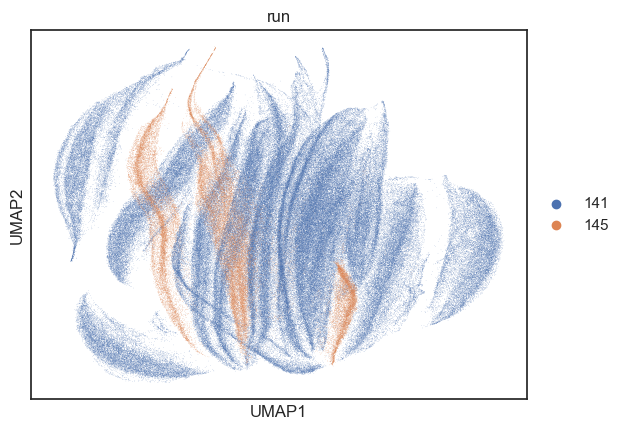

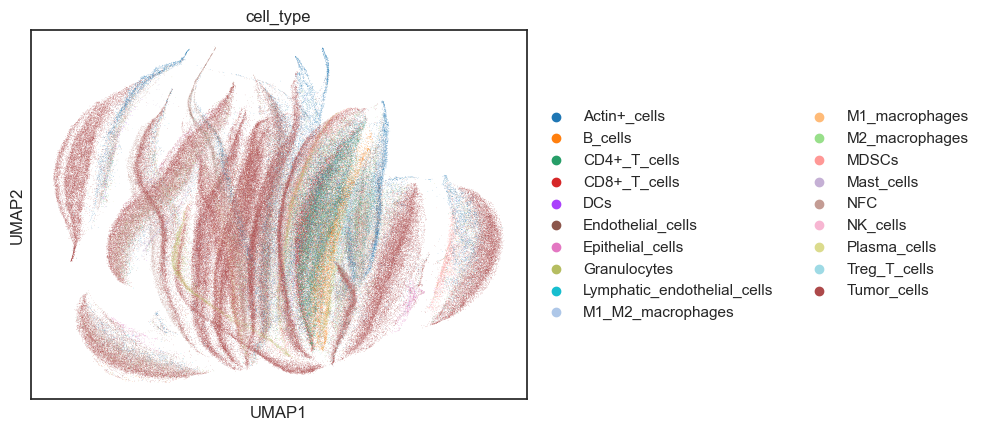

In [15]:
sc.pp.scale(adata)
sc.pp.combat(adata, key="patient_ID")
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color="patient_ID")
sc.pl.umap(adata, color="run")
sc.pl.umap(adata, color="cell_type")